In [ ]:
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.2 MB/s eta 0:00:00


In [ ]:
!kaggle datasets download -d hsankesara/flickr-image-dataset

Dataset URL: https://www.kaggle.com/datasets/hsankesara/flickr-image-dataset
License(s): CC0-1.0
100% 8.16G/8.16G [01:27<00:00, 99.6MB/s]



In [ ]:
import zipfile
import os

with zipfile.ZipFile('flickr-image-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('flickr30k_images')

print(os.listdir('flickr30k_images'))

['flickr30k_images']


In [ ]:
import os
import subprocess

REPO_DIR = "flickr30k_entities-master"

if not os.path.exists(REPO_DIR):
    subprocess.run(["wget", "-O", "master.zip", "https://github.com/BryanPlummer/flickr30k_entities/archive/refs/heads/master.zip"], check=True)
    subprocess.run(["unzip", "-o", "master.zip"], check=True)
    os.remove("master.zip")

In [ ]:
import os
import xml.etree.ElementTree as ET
from collections import defaultdict
from PIL import Image
import zipfile

IMAGE_DIR = "/content/flickr30k_images/flickr30k_images/flickr30k_images"
REPO_DIR = "flickr30k_entities-master"

if not os.path.exists(REPO_DIR):
    print("Annotation repo not found.")
    raise SystemExit(1)

ANNO_ZIP = os.path.join(REPO_DIR, "annotations.zip")
if os.path.exists(ANNO_ZIP) and not os.path.exists(os.path.join(REPO_DIR, "Annotations")):
    print("Extracting annotations...")
    with zipfile.ZipFile(ANNO_ZIP, 'r') as zip_ref:
        zip_ref.extractall(REPO_DIR)

with open(os.path.join(REPO_DIR, "test.txt"), "r") as f:
    test_image_ids = [line.strip().split('.')[0] for line in f]

print(f"Test image IDs: {len(test_image_ids)}")
print("First 5:", test_image_ids[:5])

missing = []
existing = []
for img_id in test_image_ids:
    for ext in ['.jpg', '.jpeg', '.png']:
        path = os.path.join(IMAGE_DIR, f"{img_id}{ext}")
        if os.path.exists(path):
            existing.append(img_id)
            break
    else:
        missing.append(img_id)

print(f"Images found: {len(existing)}")
if missing:
    print(f"Missing: {len(missing)} (first 5: {missing[:5]})")
else:
    print("All test images present.")

if existing:
    sample_ids = existing[:3]
    print("Loading sample images...")
    for img_id in sample_ids:
        for ext in ['.jpg', '.jpeg', '.png']:
            path = os.path.join(IMAGE_DIR, f"{img_id}{ext}")
            if os.path.exists(path):
                try:
                    img = Image.open(path).convert("RGB")
                    print(f"Loaded {img_id} ({img.size})")
                except Exception as e:
                    print(f"Failed {img_id}: {e}")
                break

if existing:
    sample_id = existing[0]
    print(f"Sample phrases for {sample_id}:")
    xml_path = os.path.join(REPO_DIR, "Annotations", f"{sample_id}.xml")
    if os.path.exists(xml_path):
        tree = ET.parse(xml_path)
        root = tree.getroot()
        chain_to_phrase = {}
        sent_path = os.path.join(REPO_DIR, "Sentences", f"{sample_id}.txt")
        if os.path.exists(sent_path):
            with open(sent_path, 'r') as f:
                lines = f.readlines()
                for line in lines[1:]:
                    if '#' in line:
                        parts = line.strip().split('#')
                        if len(parts) == 2:
                            chain_id, phrase = parts[0], parts[1]
                            chain_to_phrase[chain_id] = phrase
        for obj in root.iter('object'):
            chain_id = obj.find('name').text
            phrase = chain_to_phrase.get(chain_id, chain_id)
            print(f"  - {phrase}")
    else:
        print("  XML not found.")

print("Verification complete.")
if missing:
    print("Some images missing. Check IMAGE_DIR and file naming (e.g., 1016887272.jpg).")
else:
    print("All ready for benchmark.")

Extracting annotations...
Test image IDs: 1000
First 5: ['1016887272', '7162685234', '3000017878', '4971484184', '92679312']
Images found: 1000
All test images present.
Loading sample images...
Loaded 1016887272 ((333, 500))
Loaded 7162685234 ((500, 333))
Loaded 3000017878 ((500, 281))
Sample phrases for 1016887272:
  - 547
  - 547
  - 547
  - 547
  - 547
  - 547
  - 547
  - 548
  - 549
  - 550
  - 550
  - 551
  - 554
Verification complete.
All ready for benchmark.


In [ ]:
import os
import re
import xml.etree.ElementTree as ET
from PIL import Image

IMAGE_DIR = "flickr30k_images"
REPO_DIR = "flickr30k_entities-master"

def parse_phrases(sent_path):
    chain_to_phrase = {}
    if not os.path.exists(sent_path):
        return chain_to_phrase
    with open(sent_path, 'r') as f:
        lines = f.readlines()
        for line in lines[1:]:
            pattern = r'\[/EN#(\d+)/[^ ]+ (.*?)\]'
            matches = re.findall(pattern, line)
            for chain_id, phrase in matches:
                chain_to_phrase[chain_id] = phrase.strip()
    return chain_to_phrase

sample_id = "1016887272"
sent_path = os.path.join(REPO_DIR, "Sentences", f"{sample_id}.txt")
phrases = parse_phrases(sent_path)
print(f"Parsed phrases for image {sample_id}:")
for cid, ph in list(phrases.items())[:5]:
    print(f"   chain {cid} -> '{ph}'")

xml_path = os.path.join(REPO_DIR, "Annotations", f"{sample_id}.xml")
if os.path.exists(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    print(f"\nObjects from XML (first 5):")
    for i, obj in enumerate(root.iter('object')):
        if i >= 5:
            break
        chain_id = obj.find('name').text
        bbox_elem = obj.find('bndbox')
        if bbox_elem is not None:
            xmin = int(bbox_elem.find('xmin').text)
            ymin = int(bbox_elem.find('ymin').text)
            xmax = int(bbox_elem.find('xmax').text)
            ymax = int(bbox_elem.find('ymax').text)
            phrase = phrases.get(chain_id, chain_id)
            print(f"   chain {chain_id} -> phrase '{phrase}'  bbox: [{xmin},{ymin},{xmax},{ymax}]")



Parsed phrases for image 1016887272:
   chain 547 -> 'A collage of one person'
   chain 548 -> 'a cliff'
   chain 549 -> 'one man'
   chain 551 -> 'the rope'

Objects from XML (first 5):
   chain 547 -> phrase 'A collage of one person'  bbox: [194,370,231,454]
   chain 547 -> phrase 'A collage of one person'  bbox: [208,304,256,384]
   chain 547 -> phrase 'A collage of one person'  bbox: [188,239,227,307]
   chain 547 -> phrase 'A collage of one person'  bbox: [165,205,205,261]
   chain 547 -> phrase 'A collage of one person'  bbox: [177,164,229,215]


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...


--- Pointing Game Accuracy (400/1000) ---
Raw Attention             | 31.0%
Attention Rollout         | 6.0%
ViT-Grad-CAM              | 25.8%
Attn x Grad (Chefer)      | 38.5%
Deep-Spec (Ours)          | 51.7%
--------------------------------------------------


Evaluating:  50%|█████     | 500/1000 [28:47<28:56,  3.47s/obj]


--- Pointing Game Accuracy (500/1000) ---
Raw Attention             | 32.4%
Attention Rollout         | 5.8%
ViT-Grad-CAM              | 26.8%
Attn x Grad (Chefer)      | 38.4%
Deep-Spec (Ours)          | 51.8%
--------------------------------------------------


Evaluating:  57%|█████▋    | 567/1000 [32:42<24:58,  3.46s/obj]



    FINAL FLICKR30K POINTING GAME ACCURACY (Qwen2.5-VL)     
Method                    | Hit Acc (%)  | Variance   | Std Dev   
------------------------------------------------------------
   Raw Attention          |      32.98 |     0.2214 |     0.4706
   Attention Rollout      |       5.29 |     0.0502 |     0.2241
   ViT-Grad-CAM           |      27.34 |     0.1990 |     0.4461
   Attn x Grad (Chefer)   |      38.80 |     0.2379 |     0.4877
>> Deep-Spec (Ours)       |      51.85 |     0.2501 |     0.5001

Total Evaluated Samples: 567
------------------------------------------------------------
 EXCLUSIVE HITS (Only this method got it right) 
------------------------------------------------------------
Raw Attention             | 7
Attention Rollout         | 0
ViT-Grad-CAM              | 31
Attn x Grad (Chefer)      | 43
Deep-Spec (Ours)          | 61
------------------------------------------------------------


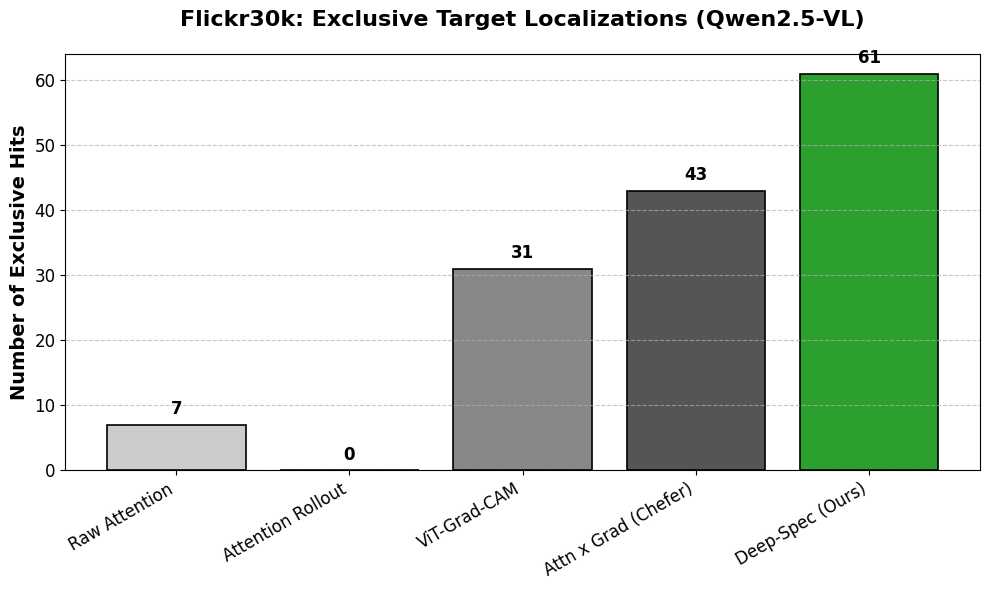

In [ ]:
import torch
import numpy as np
from scipy.linalg import eigh
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration, BitsAndBytesConfig
from tqdm import tqdm
import warnings
import logging
import os
import zipfile
import xml.etree.ElementTree as ET
from collections import defaultdict
from PIL import Image
import re
import random
import matplotlib.pyplot as plt
import gc

logging.basicConfig(level=logging.ERROR)
warnings.filterwarnings("ignore")

IMAGE_DIR = "/content/flickr30k_images/flickr30k_images/flickr30k_images"
REPO_DIR = "flickr30k_entities-master"
NUM_EVALS = 1000
SHUFFLE = True

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map={"": 0},
    attn_implementation="eager",
    low_cpu_mem_usage=True
)
model.eval()

def parse_phrases(sent_path):
    chain_to_phrase = {}
    if not os.path.exists(sent_path):
        return chain_to_phrase
    with open(sent_path, 'r') as f:
        lines = f.readlines()
        for line in lines[1:]:
            pattern = r'\[/EN#(\d+)/[^ ]+ (.*?)\]'
            matches = re.findall(pattern, line)
            for chain_id, phrase in matches:
                chain_to_phrase[chain_id] = phrase.strip()
    return chain_to_phrase

if not os.path.exists(REPO_DIR):
    import subprocess
    subprocess.run(["wget", "-O", "master.zip", "https://github.com/BryanPlummer/flickr30k_entities/archive/refs/heads/master.zip"], check=True)
    subprocess.run(["unzip", "-o", "master.zip"], check=True)
    os.remove("master.zip")

ANNO_ZIP = os.path.join(REPO_DIR, "annotations.zip")
if os.path.exists(ANNO_ZIP) and not os.path.exists(os.path.join(REPO_DIR, "Annotations")):
    with zipfile.ZipFile(ANNO_ZIP, 'r') as zip_ref:
        zip_ref.extractall(REPO_DIR)

with open(os.path.join(REPO_DIR, "test.txt"), "r") as f:
    test_image_ids = [line.strip().split('.')[0] for line in f]

image_to_objects = defaultdict(list)
for img_id in test_image_ids:
    xml_path = os.path.join(REPO_DIR, "Annotations", f"{img_id}.xml")
    if not os.path.exists(xml_path):
        continue
    try:
        tree = ET.parse(xml_path)
    except:
        continue
    root = tree.getroot()
    sent_path = os.path.join(REPO_DIR, "Sentences", f"{img_id}.txt")
    chain_to_phrase = parse_phrases(sent_path)
    for obj in root.iter('object'):
        chain_id = obj.find('name').text
        bbox_elem = obj.find('bndbox')
        if bbox_elem is None:
            continue
        xmin = int(bbox_elem.find('xmin').text)
        ymin = int(bbox_elem.find('ymin').text)
        xmax = int(bbox_elem.find('xmax').text)
        ymax = int(bbox_elem.find('ymax').text)
        phrase = chain_to_phrase.get(chain_id, chain_id)
        image_to_objects[img_id].append({
            'category_name': phrase,
            'bbox': [xmin, ymin, xmax - xmin, ymax - ymin]
        })

methods = ["Raw Attention", "Attention Rollout", "ViT-Grad-CAM", "Attn x Grad (Chefer)", "Deep-Spec (Ours)"]
hits = {m: 0 for m in methods}
results_per_sample = {m: [] for m in methods}
total_evaluated = 0

def extract_all_heatmaps(inputs, tgt_rel, img_start, img_end, text_indices, grid_h, grid_w, orig_grid_h, orig_grid_w):
    heatmaps = {}

    with torch.no_grad():
        outputs_nograd = model(**inputs, output_attentions=True)
        all_layers_attn = torch.stack(outputs_nograd.attentions).detach().cpu().squeeze(1)
        avg_attn = all_layers_attn.mean(dim=(0, 1))

        hm_raw = avg_attn[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(grid_h, grid_w)
        hm_raw = hm_raw / (hm_raw.max() + 1e-10)
        heatmaps["Raw Attention"] = hm_raw.to(torch.float32).numpy()

        S_len = avg_attn.shape[0]
        rollout = torch.eye(S_len, dtype=torch.float32)
        for layer_attn in all_layers_attn:
            avg_heads = layer_attn.mean(dim=0).to(torch.float32)
            avg_heads = 0.5 * avg_heads + 0.5 * torch.eye(S_len, dtype=torch.float32)
            rollout = rollout @ avg_heads
        hm_roll = rollout[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(grid_h, grid_w)
        hm_roll = hm_roll / (hm_roll.max() + 1e-10)
        heatmaps["Attention Rollout"] = hm_roll.numpy()

        W_c = avg_attn[text_indices][:, img_start:img_end]
        W_c = W_c / (W_c.max() + 1e-10)
        W_c_np = W_c.to(torch.float32).numpy()

        T_ds, I_ds = W_c_np.shape
        N = T_ds + I_ds
        W = np.zeros((N, N))
        W[:T_ds, T_ds:] = W_c_np
        W[T_ds:, :T_ds] = W_c_np.T
        W = W + 1e-5

        D = np.sum(W, axis=1)
        D[D == 0] = 1e-5
        D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
        L_sym = np.eye(N) - D_inv_sqrt @ W @ D_inv_sqrt
        _, eigvecs = eigh(L_sym)

        K_components = min(5, T_ds - 1) if T_ds > 5 else 1
        if K_components > 0:
            V_text = eigvecs[:T_ds, 1:K_components+1]
            V_img = eigvecs[T_ds:, 1:K_components+1]
            denoised_affinity = V_text @ V_img.T
            tgt_rel_mapped = [text_indices.index(idx) for idx in tgt_rel]
            target_affinity = np.abs(denoised_affinity[tgt_rel_mapped, :])
            hm_ds = target_affinity.max(axis=0).reshape(grid_h, grid_w)
            hm_ds = (hm_ds - hm_ds.min()) / (hm_ds.max() - hm_ds.min() + 1e-10)
            heatmaps["Deep-Spec (Ours)"] = hm_ds
        else:
            heatmaps["Deep-Spec (Ours)"] = np.zeros((grid_h, grid_w))

        del outputs_nograd
        del all_layers_attn
        gc.collect()
        torch.cuda.empty_cache()

    activations, gradients = None, None

    def fwd_hook(m, inp, out):
        nonlocal activations
        activations = out[0].detach() if isinstance(out, tuple) else out.detach()

    def bwd_hook(m, gin, gout):
        nonlocal gradients
        gradients = gout[0].detach() if isinstance(gout, tuple) else gout.detach()

    target_layer = None
    for name, m in model.named_modules():
        if ("visual.blocks" in name or "vision_tower" in name) and name.split('.')[-1].isdigit():
            target_layer = m

    h1, h2 = None, None
    if target_layer is not None:
        h1 = target_layer.register_forward_hook(fwd_hook)
        h2 = target_layer.register_full_backward_hook(bwd_hook)

    if "pixel_values" in inputs:
        inputs["pixel_values"].requires_grad_(True)
    if "image_features" in inputs and inputs["image_features"].is_floating_point():
        inputs["image_features"].requires_grad_(True)

    model.zero_grad()

    try:
        outputs = model(**inputs, output_attentions=True, output_hidden_states=True)

        if hasattr(outputs, 'logits'):
            del outputs.logits

        for a in outputs.attentions:
            a.retain_grad()

        loss = outputs.hidden_states[-1][0, tgt_rel].sum()
        loss.backward()

        if gradients is not None and activations is not None:
            acts = activations[0] if activations.dim() == 3 else activations
            grads = gradients[0] if gradients.dim() == 3 else gradients

            if acts.shape[0] == orig_grid_h * orig_grid_w:
                weights = grads.mean(dim=0)
                cam = (weights * acts).sum(dim=-1)
                cam = torch.relu(cam)
                cam = cam.reshape(1, 1, orig_grid_h, orig_grid_w)
                cam = torch.nn.functional.interpolate(cam.float(), size=(grid_h, grid_w), mode='bilinear').squeeze()
                if cam.max() > 0: cam = cam / (cam.max() + 1e-10)
                heatmaps["ViT-Grad-CAM"] = cam.detach().cpu().to(torch.float32).numpy()
            else:
                heatmaps["ViT-Grad-CAM"] = np.zeros((grid_h, grid_w))
        else:
            heatmaps["ViT-Grad-CAM"] = np.zeros((grid_h, grid_w))

        heatmap_chefer = torch.zeros((S_len, S_len), device="cpu", dtype=torch.float32)
        count = 0
        for a in outputs.attentions:
            if a.grad is not None:
                grad = a.grad.detach().cpu().to(torch.float32).squeeze(0)
                attn = a.detach().cpu().to(torch.float32).squeeze(0)
                heatmap_chefer += (attn * grad).mean(dim=0)
                count += 1

        if count > 0:
            heatmap_chefer = heatmap_chefer / count
            heatmap_chefer = torch.clamp(heatmap_chefer, min=0)
            hm_chefer = heatmap_chefer[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(grid_h, grid_w)
            if hm_chefer.max() > 0: hm_chefer = hm_chefer / (hm_chefer.max() + 1e-10)
            heatmaps["Attn x Grad (Chefer)"] = hm_chefer.numpy()
        else:
            heatmaps["Attn x Grad (Chefer)"] = np.zeros((grid_h, grid_w))

    except Exception:
        heatmaps["ViT-Grad-CAM"] = np.zeros((grid_h, grid_w))
        heatmaps["Attn x Grad (Chefer)"] = np.zeros((grid_h, grid_w))
    finally:
        if h1 is not None: h1.remove()
        if h2 is not None: h2.remove()
        if 'outputs' in locals(): del outputs
        gc.collect()
        torch.cuda.empty_cache()

    return heatmaps

if SHUFFLE:
    random.shuffle(test_image_ids)

print("\n--- Starting Evaluation Run on Flickr30k ---")
with tqdm(total=NUM_EVALS, desc="Evaluating", unit="obj") as pbar:
    for img_id in test_image_ids:
        if total_evaluated >= NUM_EVALS:
            break
        if img_id not in image_to_objects:
            continue
        objects = image_to_objects[img_id]
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png']:
            candidate = os.path.join(IMAGE_DIR, f"{img_id}{ext}")
            if os.path.exists(candidate):
                img_path = candidate
                break
        if img_path is None:
            continue

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            continue
        orig_W, orig_H = image.size

        sent_path = os.path.join(REPO_DIR, "Sentences", f"{img_id}.txt")
        if not os.path.exists(sent_path):
            continue
        with open(sent_path, 'r') as f:
            caption = f.readline().strip()
        if not caption:
            continue

        target_noun = None
        for obj in objects:
            phrase = obj['category_name']
            if phrase.lower() in caption.lower():
                target_noun = phrase
                break
        if not target_noun:
            continue

        all_target_bboxes = [obj['bbox'] for obj in objects if obj['category_name'] == target_noun]

        image_copy = image.copy()
        image_copy.thumbnail((512, 512))

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": caption}
                ]
            }
        ]

        prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[prompt], images=[image_copy], return_tensors="pt").to(model.device)
        input_ids = inputs["input_ids"][0].tolist()

        if "image_grid_thw" not in inputs: continue
        thw = inputs["image_grid_thw"][0]
        orig_grid_h, orig_grid_w = thw[1].item(), thw[2].item()
        grid_h, grid_w = orig_grid_h // 2, orig_grid_w // 2

        tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)
        if "<|vision_start|>" not in tokens or "<|vision_end|>" not in tokens: continue

        img_start = tokens.index("<|vision_start|>") + 1
        img_end = tokens.index("<|vision_end|>")

        if (img_end - img_start) != (grid_h * grid_w): continue

        text_indices = list(range(img_end + 1, len(input_ids)))
        if not text_indices: continue

        target_indices = []
        target_words = target_noun.lower().split()
        for i in text_indices:
            t = tokens[i].lower().replace("ġ", "").replace("ĉ", "").replace(" ", "").replace("_", "")
            if t in target_words:
                target_indices.append(i)

        if not target_indices: continue
        tgt_rel = target_indices

        heatmaps = extract_all_heatmaps(inputs, tgt_rel, img_start, img_end, text_indices, grid_h, grid_w, orig_grid_h, orig_grid_w)
        if heatmaps is None: continue

        for m_name in methods:
            hm = heatmaps[m_name]
            if hm.max() == 0:
                results_per_sample[m_name].append(0)
                continue

            max_idx = np.argmax(hm)
            max_y_patch, max_x_patch = np.unravel_index(max_idx, hm.shape)
            rel_x = (max_x_patch + 0.5) / grid_w
            rel_y = (max_y_patch + 0.5) / grid_h
            pixel_x = rel_x * orig_W
            pixel_y = rel_y * orig_H

            hit = False
            for bbox in all_target_bboxes:
                x_min, y_min, bbox_w, bbox_h = bbox
                x_max, y_max = x_min + bbox_w, y_min + bbox_h
                if (x_min <= pixel_x <= x_max) and (y_min <= pixel_y <= y_max):
                    hit = True
                    break

            if hit: hits[m_name] += 1
            results_per_sample[m_name].append(1 if hit else 0)

        total_evaluated += 1
        pbar.update(1)

        if total_evaluated % 100 == 0:
            pbar.write(f"\n--- Pointing Game Accuracy ({total_evaluated}/{NUM_EVALS}) ---")
            for m_name in methods:
                acc = (hits[m_name] / total_evaluated) * 100
                pbar.write(f"{m_name:<25} | {acc:.1f}%")
            pbar.write("-" * 50)

print("\n" + "=" * 60)
print(" FINAL FLICKR30K POINTING GAME ACCURACY (Qwen2.5-VL) ".center(60))
print("=" * 60)
print(f"{'Method':<25} | {'Hit Acc (%)':<12} | {'Variance':<10} | {'Std Dev':<10}")
print("-" * 60)
for m_name in methods:
    arr = np.array(results_per_sample[m_name])
    acc = arr.mean() * 100 if len(arr) > 0 else 0
    var = arr.var(ddof=1) if len(arr) > 1 else 0.0
    std = arr.std(ddof=1) if len(arr) > 1 else 0.0
    prefix = ">> " if "Deep-Spec" in m_name else "   "
    print(f"{prefix}{m_name:<22} | {acc:>10.2f} | {var:>10.4f} | {std:>10.4f}")
print("=" * 60)

num_samples = len(results_per_sample["Deep-Spec (Ours)"])
exclusive_hits_count = {m: 0 for m in methods}
for i in range(num_samples):
    hits_for_sample = [m for m in methods if results_per_sample[m][i] == 1]
    if len(hits_for_sample) == 1:
        exclusive_m = hits_for_sample[0]
        exclusive_hits_count[exclusive_m] += 1

print(f"\nTotal Evaluated Samples: {num_samples}")
print("-" * 60)
print(" EXCLUSIVE HITS (Only this method got it right) ")
print("-" * 60)
for m in methods:
    print(f"{m:<25} | {exclusive_hits_count[m]}")
print("-" * 60)

plt.figure(figsize=(10, 6))
colors = ['#cccccc', '#aaaaaa', '#888888', '#555555', '#2ca02c']
bars = plt.bar(methods, [exclusive_hits_count[m] for m in methods], color=colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title("Flickr30k: Exclusive Target Localizations (Qwen2.5-VL)", fontsize=16, pad=20, fontweight='bold')
plt.ylabel("Number of Exclusive Hits", fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

pdf_filename = "Deep_Spec_Exclusive_Hits_Qwen2_5_VL_flickr30k.pdf"
plt.savefig(pdf_filename, format="pdf", dpi=300, bbox_inches='tight')
plt.show()